In [19]:
# %%
# nn.py

In [20]:
# %%
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn import neural_network
from sklearn.datasets import load_breast_cancer
from sklearn.decomposition import PCA, FastICA
from sklearn.model_selection import GridSearchCV, learning_curve, train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.random_projection import GaussianRandomProjection

sns.set_theme(style="whitegrid")
os.makedirs("./result", exist_ok=True)

In [21]:
# %%
# Load the Breast Cancer dataset
bc_data = load_breast_cancer()
X = bc_data.data
y = bc_data.target

# Standardize features
scaler = StandardScaler()
X = scaler.fit_transform(X)

# One-hot encode the target
encoder = OneHotEncoder(sparse_output=False)
y = encoder.fit_transform(y.reshape(-1, 1))

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [22]:
# %%
# Apply dimensionality reduction techniques
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

ica = FastICA(n_components=2, random_state=42)
X_train_ica = ica.fit_transform(X_train)
X_test_ica = ica.transform(X_test)

rp = GaussianRandomProjection(n_components=2, random_state=42)
X_train_rp = rp.fit_transform(X_train)
X_test_rp = rp.transform(X_test)

In [23]:
# %%
# Train a neural network classifier
NeuralNetwork = neural_network.MLPClassifier(max_iter=3000, random_state=42)
param_grid = {
    "hidden_layer_sizes": np.arange(2, 50, 2),
    "activation": ["logistic", "relu", "tanh"],
    "solver": ["adam", "sgd"],
    "alpha": [0.001, 0.01, 0.1],
    "learning_rate": ["invscaling", "adaptive"],
    "learning_rate_init": [0.001, 0.01, 0.1],
}


def fit_and_evaluate(X_train, X_test, y_train, y_test, method_name):
    NeuralNetworkCV = GridSearchCV(
        NeuralNetwork, param_grid, cv=5, n_jobs=2, verbose=0, pre_dispatch="2*n_jobs"
    )
    NeuralNetworkCV.fit(X_train, y_train)
    print(f"Best parameters ({method_name}): {NeuralNetworkCV.best_params_}")

    train_score = NeuralNetworkCV.score(X_train, y_train)
    test_score = NeuralNetworkCV.score(X_test, y_test)
    print(f"Train accuracy ({method_name}): {train_score:.4f}")
    print(f"Test accuracy ({method_name}): {test_score:.4f}")

    BestNeuralNetwork = NeuralNetworkCV.best_estimator_
    train_sizes, train_scores, test_scores = learning_curve(
        BestNeuralNetwork,
        X_train,
        y_train,
        cv=5,
        train_sizes=np.linspace(0.1, 1.0, 20),
    )

    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)

    plt.figure(figsize=(12, 8))
    plt.fill_between(
        train_sizes,
        train_scores_mean - train_scores_std,
        train_scores_mean + train_scores_std,
        alpha=0.1,
        color="b",
    )
    plt.fill_between(
        train_sizes,
        test_scores_mean - test_scores_std,
        test_scores_mean + test_scores_std,
        alpha=0.1,
        color="r",
    )
    plt.plot(train_sizes, train_scores_mean, "o-", color="b", label="Training score")
    plt.plot(
        train_sizes, test_scores_mean, "o-", color="r", label="Cross-validation score"
    )
    plt.title(f"Learning Curve ({method_name})")
    plt.xlabel("Training examples")
    plt.ylabel("Score")
    plt.legend(loc="best")
    plt.savefig(f"./result/learning_curve_{method_name.lower()}.png")
    plt.show()

    return NeuralNetworkCV.best_estimator_, train_score, test_score

Best parameters (Original): {'activation': 'logistic', 'alpha': 0.1, 'hidden_layer_sizes': np.int64(42), 'learning_rate': 'invscaling', 'learning_rate_init': 0.1, 'solver': 'adam'}
Train accuracy (Original): 0.9824
Test accuracy (Original): 0.9912


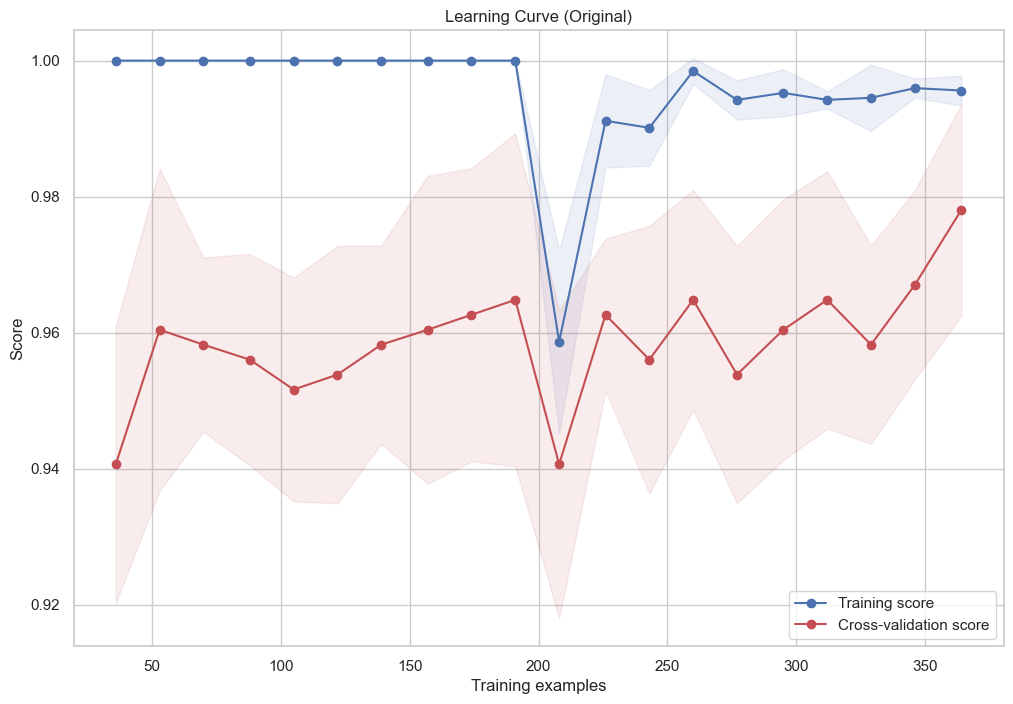

In [24]:
# %%
# Evaluate on original data
best_nn_original, train_score_original, test_score_original = fit_and_evaluate(
    X_train, X_test, y_train, y_test, "Original"
)

/opt/homebrew/Caskroom/miniconda/base/envs/ml/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (3000) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/envs/ml/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (3000) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/envs/ml/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (3000) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/envs/ml/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (3000) reached 

Best parameters (PCA): {'activation': 'relu', 'alpha': 0.001, 'hidden_layer_sizes': np.int64(2), 'learning_rate': 'invscaling', 'learning_rate_init': 0.01, 'solver': 'adam'}
Train accuracy (PCA): 0.9473
Test accuracy (PCA): 0.9912


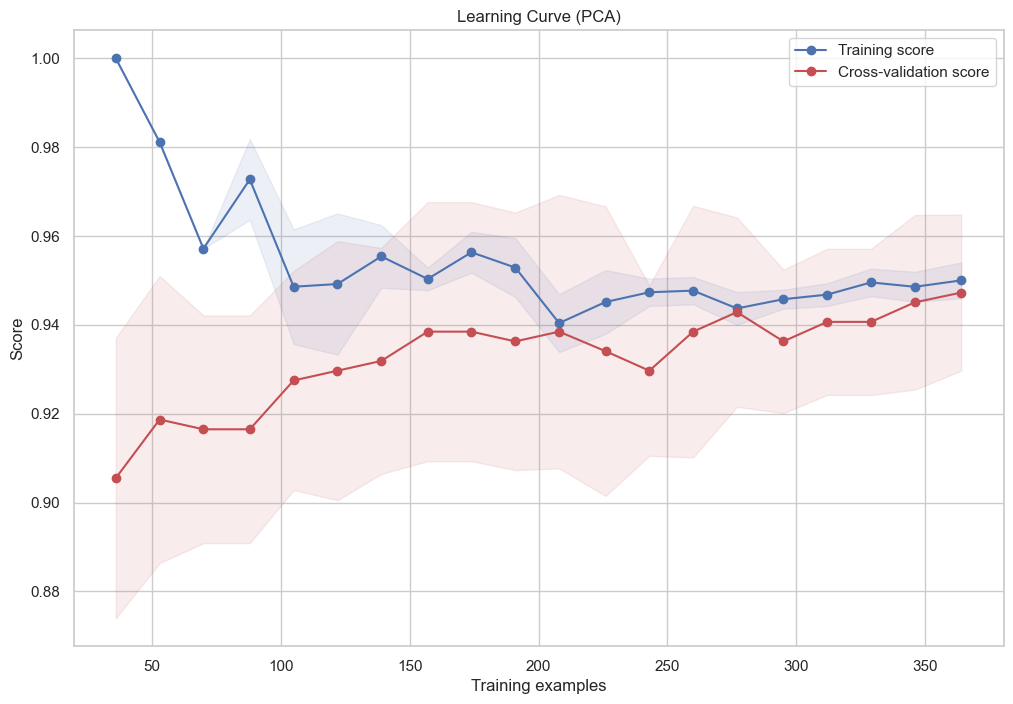

In [25]:
# Evaluate on PCA data
best_nn_pca, train_score_pca, test_score_pca = fit_and_evaluate(
    X_train_pca, X_test_pca, y_train, y_test, "PCA"
)

Best parameters (ICA): {'activation': 'logistic', 'alpha': 0.001, 'hidden_layer_sizes': np.int64(14), 'learning_rate': 'invscaling', 'learning_rate_init': 0.1, 'solver': 'adam'}
Train accuracy (ICA): 0.9495
Test accuracy (ICA): 0.9912


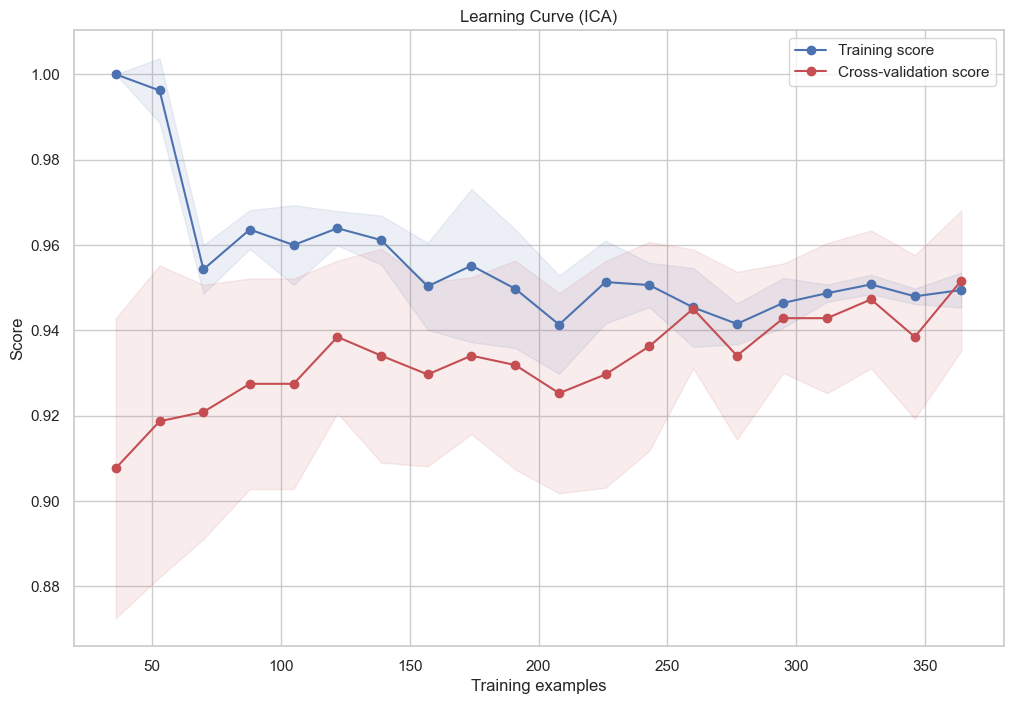

In [26]:
# Evaluate on ICA data
best_nn_ica, train_score_ica, test_score_ica = fit_and_evaluate(
    X_train_ica, X_test_ica, y_train, y_test, "ICA"
)

Best parameters (RP): {'activation': 'logistic', 'alpha': 0.01, 'hidden_layer_sizes': np.int64(34), 'learning_rate': 'invscaling', 'learning_rate_init': 0.01, 'solver': 'adam'}
Train accuracy (RP): 0.7780
Test accuracy (RP): 0.7632


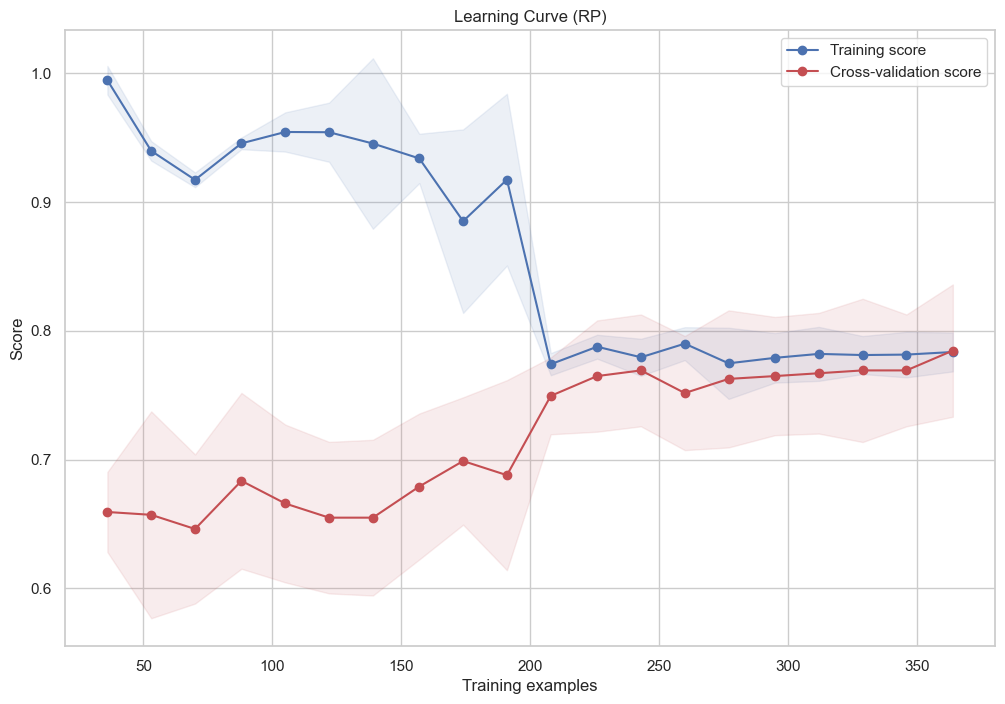

In [27]:
# Evaluate on RP data
best_nn_rp, train_score_rp, test_score_rp = fit_and_evaluate(
    X_train_rp, X_test_rp, y_train, y_test, "RP"
)

In [28]:
# %%
# Compile results into a DataFrame
results = {
    "Method": ["Original", "PCA", "ICA", "RP"],
    "Train Accuracy": [
        train_score_original,
        train_score_pca,
        train_score_ica,
        train_score_rp,
    ],
    "Test Accuracy": [
        test_score_original,
        test_score_pca,
        test_score_ica,
        test_score_rp,
    ],
}

results_df = pd.DataFrame(results)
print(results_df)

results_df.to_excel("./result/nn_performance_comparison.xlsx", index=False)

print("Results saved to './result/nn_performance_comparison.xlsx'")

     Method  Train Accuracy  Test Accuracy
0  Original        0.982418       0.991228
1       PCA        0.947253       0.991228
2       ICA        0.949451       0.991228
3        RP        0.778022       0.763158
Results saved to './result/nn_performance_comparison.xlsx'


In [29]:
# %%